
# Time Series Decomposition — What & Why

## ✅ What is Time Series Decomposition?

Time series decomposition means breaking a time series into components:

\`\`\`
Y(t) = Trend + Seasonality + Residual
\`\`\`

### **Additive Model**
\`\`\`
Y(t) = T(t) + S(t) + R(t)
\`\`\`
Used when seasonal variations are **constant**.(data is stationary)

### **Multiplicative Model**
\`\`\`
Y(t) = T(t) × S(t) × R(t)
\`\`\`
Used when seasonal variations **change with the trend**.(data is not stationary)

---

## 📦 Components

| Component | Meaning | Example |
|---|---|---|
| **Trend (T)** | Long-term movement | GDP rising over years |
| **Seasonality (S)** | Repeating pattern | Holiday season boosts sales |
| **Residual (R)** | Random noise | Unexpected market shock |

---

## ✅ Why Do We Decompose a Time Series?

| Reason | Purpose |
|---|---|
Understand data | Identify trend/seasonality/noise |
Better forecasting | Helps models like SARIMA, Holt‑Winters |
Make stationary | Remove trend/seasonality for ARIMA |
Anomaly detection | Large residuals show anomalies |
Feature engineering | Trend/seasonality as ML features |

---

## ✅ When to Use Decomposition

| Situation | Why |
|---|---|
Visible trend | Remove trend before modeling |
Seasonal effects | Handle repeating patterns |
Forecasting | Improves predictions |
Outlier detection | Spot abnormal behavior |

---

In [1]:
import pandas as pd

In [2]:
df=pd.read_csv('https://raw.githubusercontent.com/srivatsan88/YouTubeLI/master/dataset/amazon_revenue_profit.csv')

In [20]:
df['Quarter']=pd.to_datetime(df['Quarter'])
df.sort_values(by='Quarter',inplace=True)
df.set_index('Quarter',inplace=True)
df.head()

,Revenue,Net Income
Quarter,,
2005-03-31,1902,78
2005-06-30,1753,52
2005-09-30,1858,30
2005-12-31,2977,199
2006-03-31,2279,51


In [27]:
import plotly.express as px
fig=px.line(df,x=df.index,y='Revenue')
fig.update_xaxes(rangeslider_visible=True)
fig.show()

## some time series model's like arima are for stationary data
## for checking whether data is stationary or not we can check it by kpss test
<img src="https://i.postimg.cc/BZM3gfnS/image.png">
<img src="https://i.postimg.cc/nMbNL217/image.png">

In [22]:
from statsmodels.tsa.stattools import kpss
kpss(df['Revenue'],'ct')

/tmp/ipython-input-1055051531.py:2: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.




(np.float64(0.3066554597516975),
 np.float64(0.01),
 4,
 {'10%': 0.119, '5%': 0.146, '2.5%': 0.176, '1%': 0.216})

In [28]:
# data is not stationary so multiplicative model
import statsmodels.api as sm

res=sm.tsa.seasonal_decompose(x=df['Revenue'],model='multiplicative')

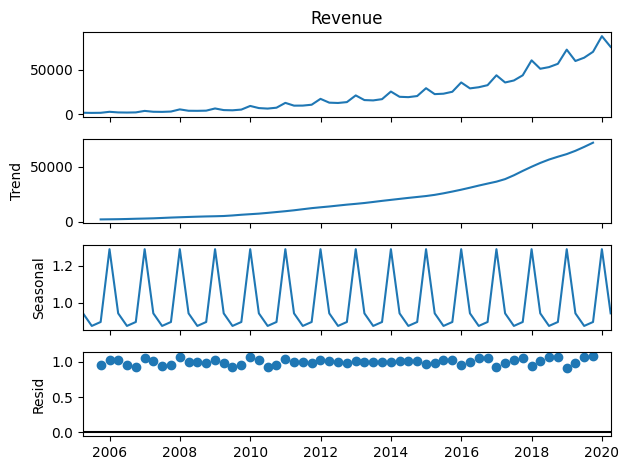

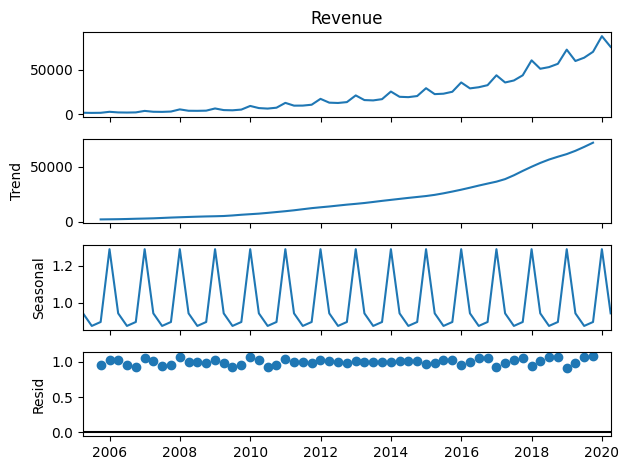

In [26]:
res.plot()

<Axes: xlabel='Quarter'>

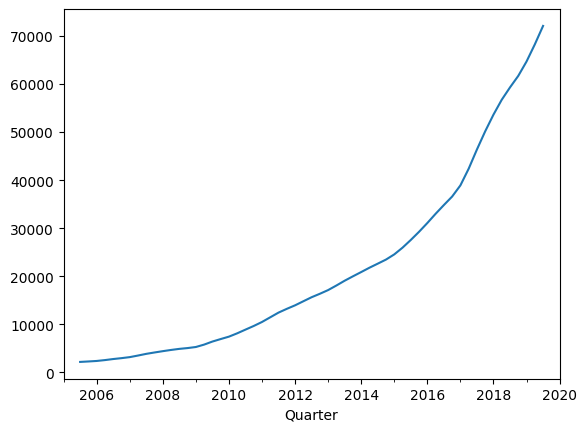

In [31]:
res.trend.plot()

In [41]:
# original value = trend*residual*seasional as multiplicative model
new_df=pd.DataFrame(res.trend*res.seasonal*res.resid)
new_df['original']=df['Revenue'].values

In [42]:
new_df

,0,original
Quarter,,
2005-03-31,NaN,1902
2005-06-30,NaN,1753
2005-09-30,1858.0,1858
2005-12-31,2977.0,2977
2006-03-31,2279.0,2279
...,...,...
2019-03-31,59700.0,59700
2019-06-30,63404.0,63404
2019-09-30,69981.0,69981


<Axes: xlabel='Quarter'>

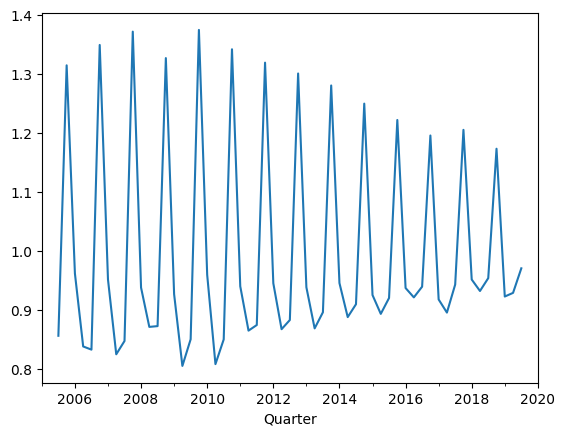

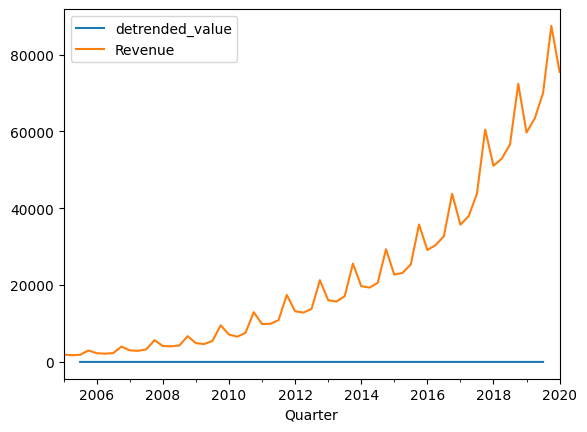

In [47]:
# detrending -> removing trend -> observed value(original value) / trend in multiplicative model , observed value(original value) - trend in additive model
df['detrended_value']=res.observed/res.trend
df['detrended_value'].plot()
df[['detrended_value','Revenue']].plot()